# **Problem Statement**

## Context

AllLife Bank wants to focus on its credit card customer base in the next financial year. They have been advised by their marketing research team, that the penetration in the market can be improved. Based on this input, the Marketing team proposes to run personalized campaigns to target new customers as well as upsell to existing customers. Another insight from the market research was that the customers perceive the support services of the back poorly. Based on this, the Operations team wants to upgrade the service delivery model, to ensure that customer queries are resolved faster. The Head of Marketing and Head of Delivery both decide to reach out to the Data Science team for help


## Objective

To identify different segments in the existing customers, based on their spending patterns as well as past interaction with the bank, using clustering algorithms, and provide recommendations to the bank on how to better market to and service these customers.

## Data Description

The data provided is of various customers of a bank and their financial attributes like credit limit, the total number of credit cards the customer has, and different channels through which customers have contacted the bank for any queries (including visiting the bank, online, and through a call center).

Data Dictionary
- Sl_No: Primary key of the records
- Customer Key: Customer identification number
- Average Credit Limit: Average credit limit of each customer for all credit cards
- Total credit cards: Total number of credit cards possessed by the customer
- Total visits bank: Total number of visits that the customer made (yearly) personally to the bank
- Total visits online: Total number of visits or online logins made by the customer (yearly)
- Total calls made: Total number of calls made by the customer to the bank or its customer service department (yearly)

# **Importing necessary libraries**

In [23]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

# to perform PCA
from sklearn.decomposition import PCA

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

# **Loading the dataset**

In [32]:
# Loading the drive
from google.colab import drive # importing/linking the google drive with google colab.
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
# Loading and displaying the data

path="/content/drive/My Drive/CCC_Data.csv" # Loading the dataset 'Credit_Card_Customer_Data.csv' as csv file into google colab.
data = pd.read_csv(path) # Reading the dataset
data.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


# **Overview of the Dataset**

The initial steps to get an overview of any dataset is to:
- observe the first few rows of the dataset, to check whether the dataset has been loaded properly or not
- get information about the number of rows and columns in the dataset
- find out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.
- check the statistical summary of the dataset to get an overview of the numerical columns of the data

## Displaying first 5 and last 5 rows of the dataset

In [34]:
# viewing the first 5 rows of the data
data.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [35]:
data.tail()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0
659,660,80150,167000,9,0,12,2


## Checking the shape of the dataset

In [36]:
data.shape

(660, 7)

* The dataset has 660 rows and 7 columns

## Creating a copy of original data

In [37]:
# copying the data to another variable to avoid any changes to original data
df = data.copy()

In [38]:
# we will drop the CountryID column add it adds no value to the analysis
df.drop("Sl_No", axis=1, inplace=True)

# we will drop the Customer Key column add it adds no value to the analysis
df.drop("Customer Key", axis=1, inplace=True)

## Checking the data types of the columns for the dataset

In [39]:
# checking datatypes and number of non-null values for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Avg_Credit_Limit     660 non-null    int64
 1   Total_Credit_Cards   660 non-null    int64
 2   Total_visits_bank    660 non-null    int64
 3   Total_visits_online  660 non-null    int64
 4   Total_calls_made     660 non-null    int64
dtypes: int64(5)
memory usage: 25.9 KB


**Observations**

- There are no columns with null entries and all are numeric data

## Checking the missing values

In [40]:
# checking for missing values
df.isnull().sum()

,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0


- As seen previously, no columns have null values.

# **Data Preprocessing**

## Checking for duplicates values

In [41]:
# checking for duplicate values
df.duplicated().sum()

np.int64(11)

- There are no duplicate values in the data.

## Statistical summary of the dataset

In [42]:
# let's look at the statistical summary of the data
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
Avg_Credit_Limit,660.0,34574.242424,37625.487804,3000.0,10000.0,18000.0,48000.0,200000.0
Total_Credit_Cards,660.0,4.706061,2.167835,1.0,3.0,5.0,6.0,10.0
Total_visits_bank,660.0,2.403030,1.631813,0.0,1.0,2.0,4.0,5.0
Total_visits_online,660.0,2.606061,2.935724,0.0,1.0,2.0,4.0,15.0
Total_calls_made,660.0,3.583333,2.865317,0.0,1.0,3.0,5.0,10.0


**Observations**

- Average credit limit range is high from 3000 to 2,00,000 with a median of 18000. Hence data is right skewed. Scaling can help reduce the variability before clustering
- Most customers visit the bank 1 to 3 times. This variable is tightly distributed, so it may have less impact unless normalized.
- Many customers barely use online services, but a few are highly active. Data is right skewed. This could be a strong differentiator in clustering.
- Possibility of Outliers in the data, which may impact the centroids.


# **Exploratory Data Analysis**

## Functions for EDA

In [43]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

## Univariate analysis

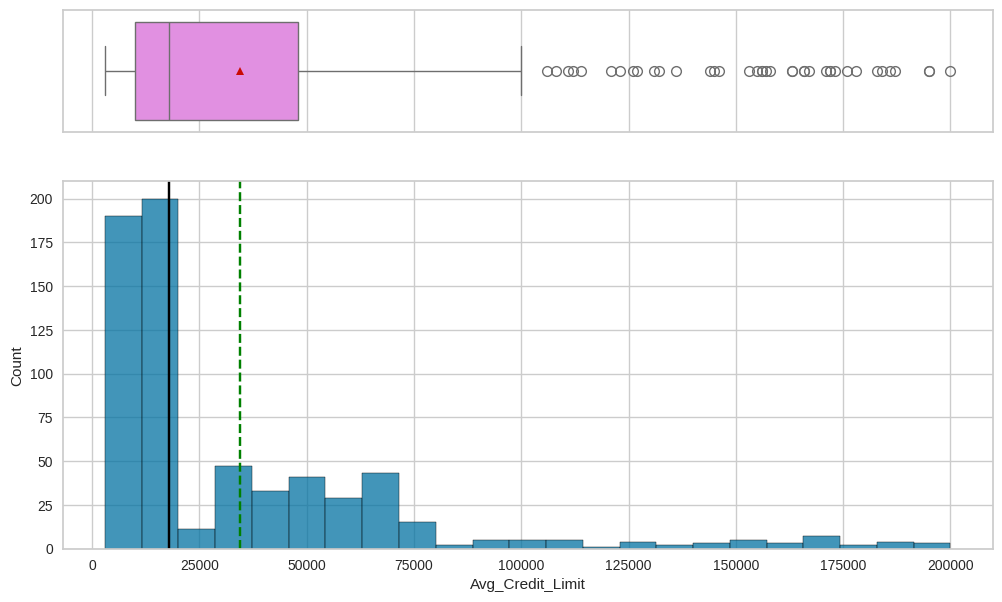

In [45]:
histogram_boxplot(df, "Avg_Credit_Limit")

- Data is heavily right skewed which means most of the customers have lesser credit limit.
- Outliers show many of the customers have higher credit limit indicating these customers can be segmented seperately

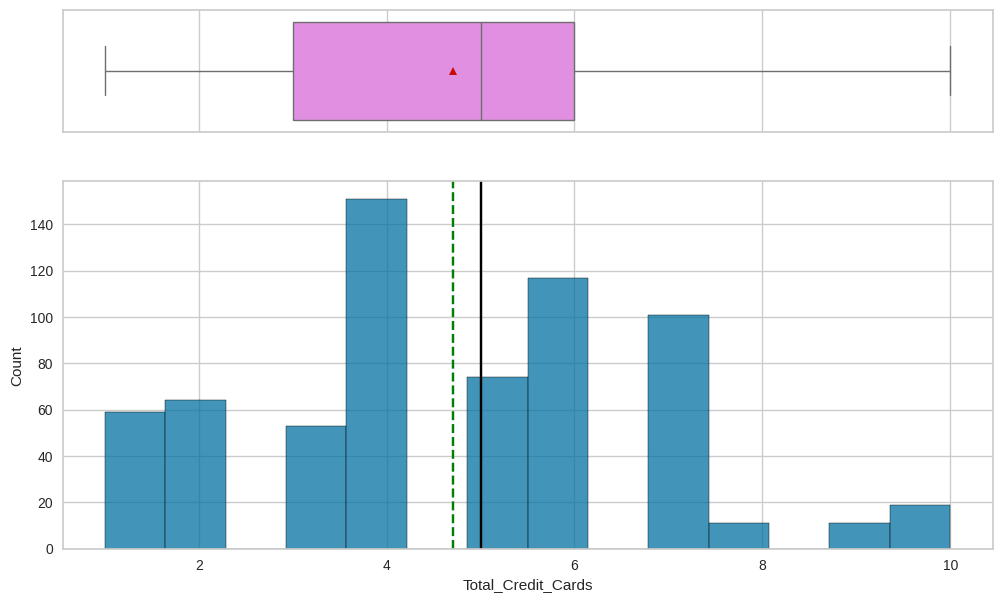

In [46]:
histogram_boxplot(df, "Total_Credit_Cards")

- Data seems normally distributed with no outliers in it.
- This variable can be used to group customers into various segment like Few cards category(1-3), Moderate cards(4-6), Many cards(7+) which helps us easily observe and interpret the data.


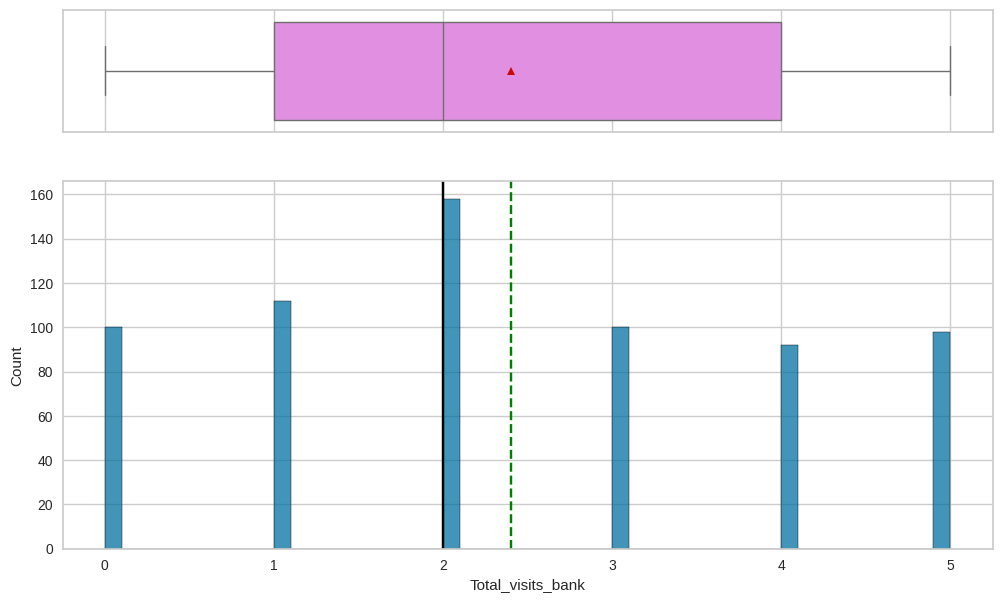

In [48]:
histogram_boxplot(df, "Total_visits_bank", bins=50)

- The above visual indicates most of the customers visit the bank atleast twice. So they so less exposure to the bank and heavy online presence

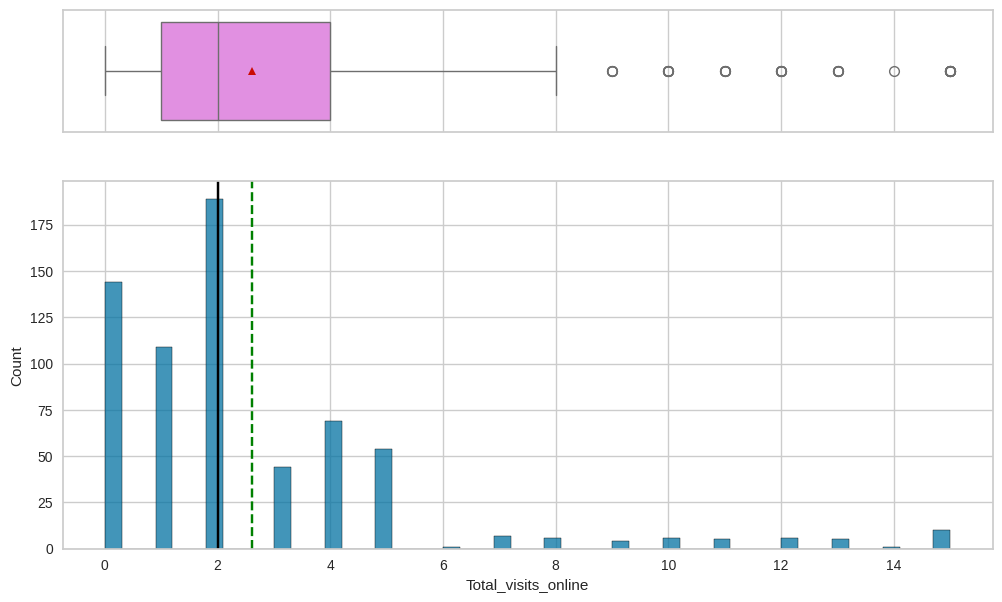

In [49]:
histogram_boxplot(df, "Total_visits_online", bins=50)

- The graph indicates most of the customers visit online atleast 0-5 times.
- The outliers indicates some users who are more active online compared to others and they can be grouped seperately.

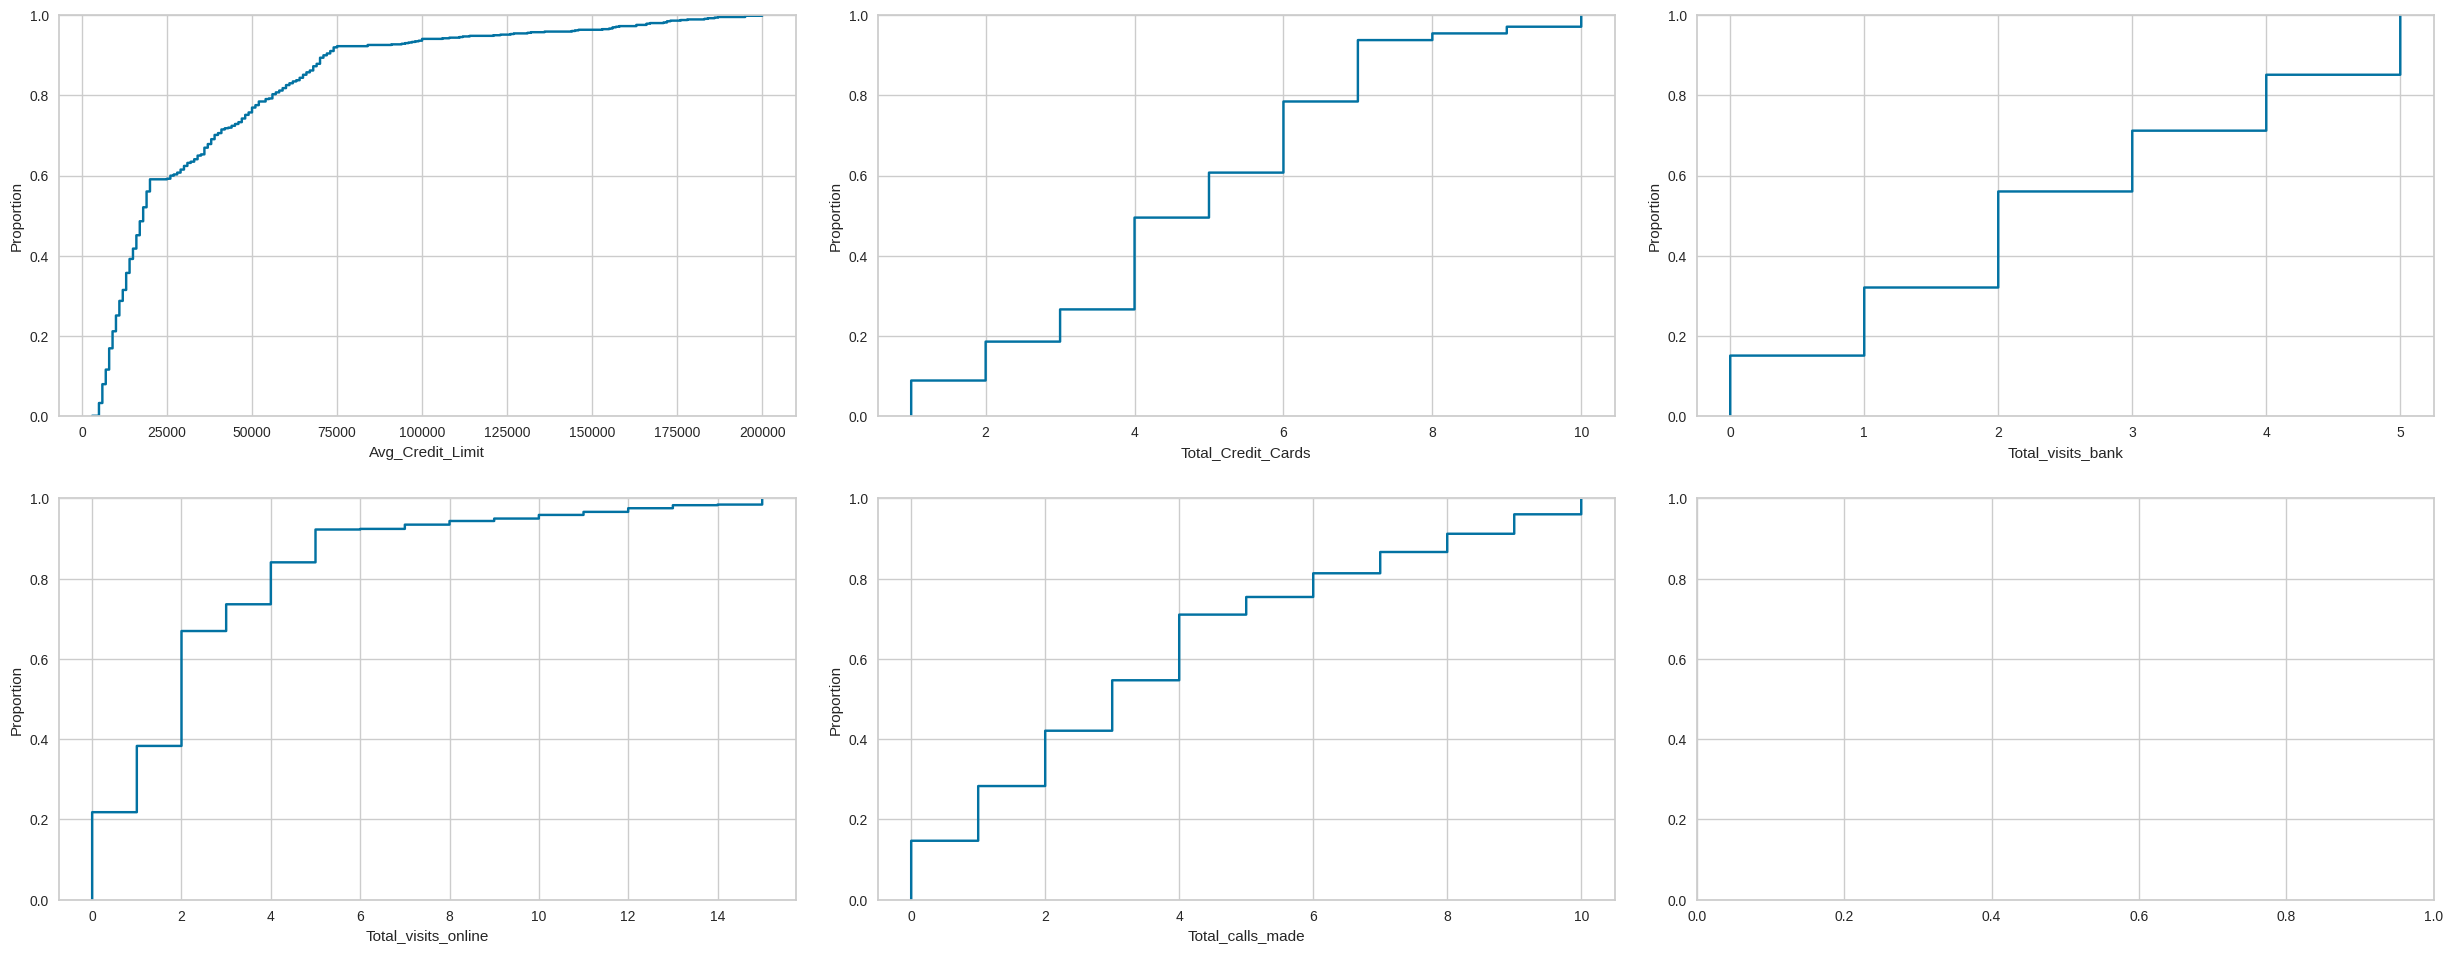

In [52]:
cols_list = df.select_dtypes(include=np.number).columns.to_list()

fig, axes = plt.subplots(2, 3, figsize=(25, 10))
counter = 0

for ii in range(2):
    for jj in range(3):
        if counter < len(cols_list):
            sns.ecdfplot(ax=axes[ii][jj], x=df[cols_list[counter]])
            counter = counter + 1


fig.tight_layout(pad=2.0)

**Observations**

- Avg credit limit shows a steep rise then fall. indicating strong eearly influence, high limits
- Total credit cards show a step wise increase, in which each additional card is adding the value.
- Gradual stepwise rise in total bank visits indicate a higher customer engagement.
- Total bank calls shows a similar pattern indicate most customers prefer online or offline service as they are dissatisfied with the call services.

## Bivariate Analysis

**Let's check for correlations.**

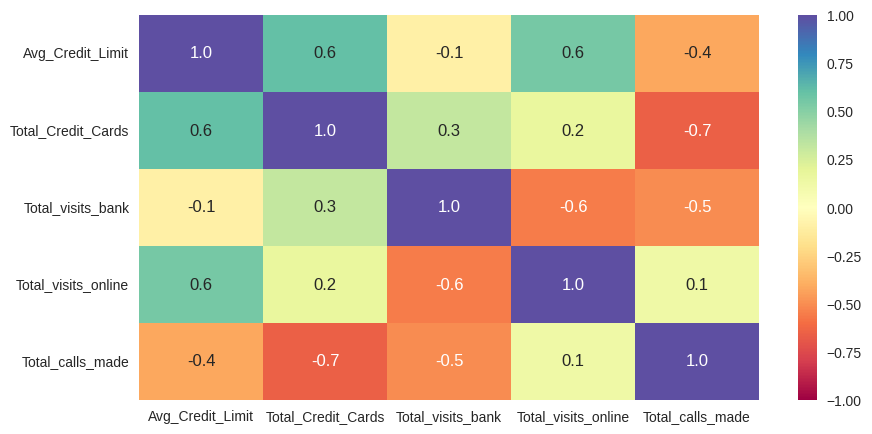

In [54]:
plt.figure(figsize=(10, 5))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".1f", cmap="Spectral"
)
plt.show()

**Observations**

- Avg credit limit shows and total credit cards show a 0.6 strong correlation. this means more cards mean higher credit limit.
- Total visits to the bank and total calls made online again show correlation of 0.5 possibily indicating service issues.
- There is a strong negative correlation with total credit cards and calls made, inidicating customers are mostly satisfied with the service.
- Visits to a bank online and offline also shows a negative correlation indicating the service is fulfilled online. This is a good point to focus for creating or enhancing online presence.
- Total calls made and visiting online also show stronger negative correlation indicating the more need for techno savy sources than offline services.

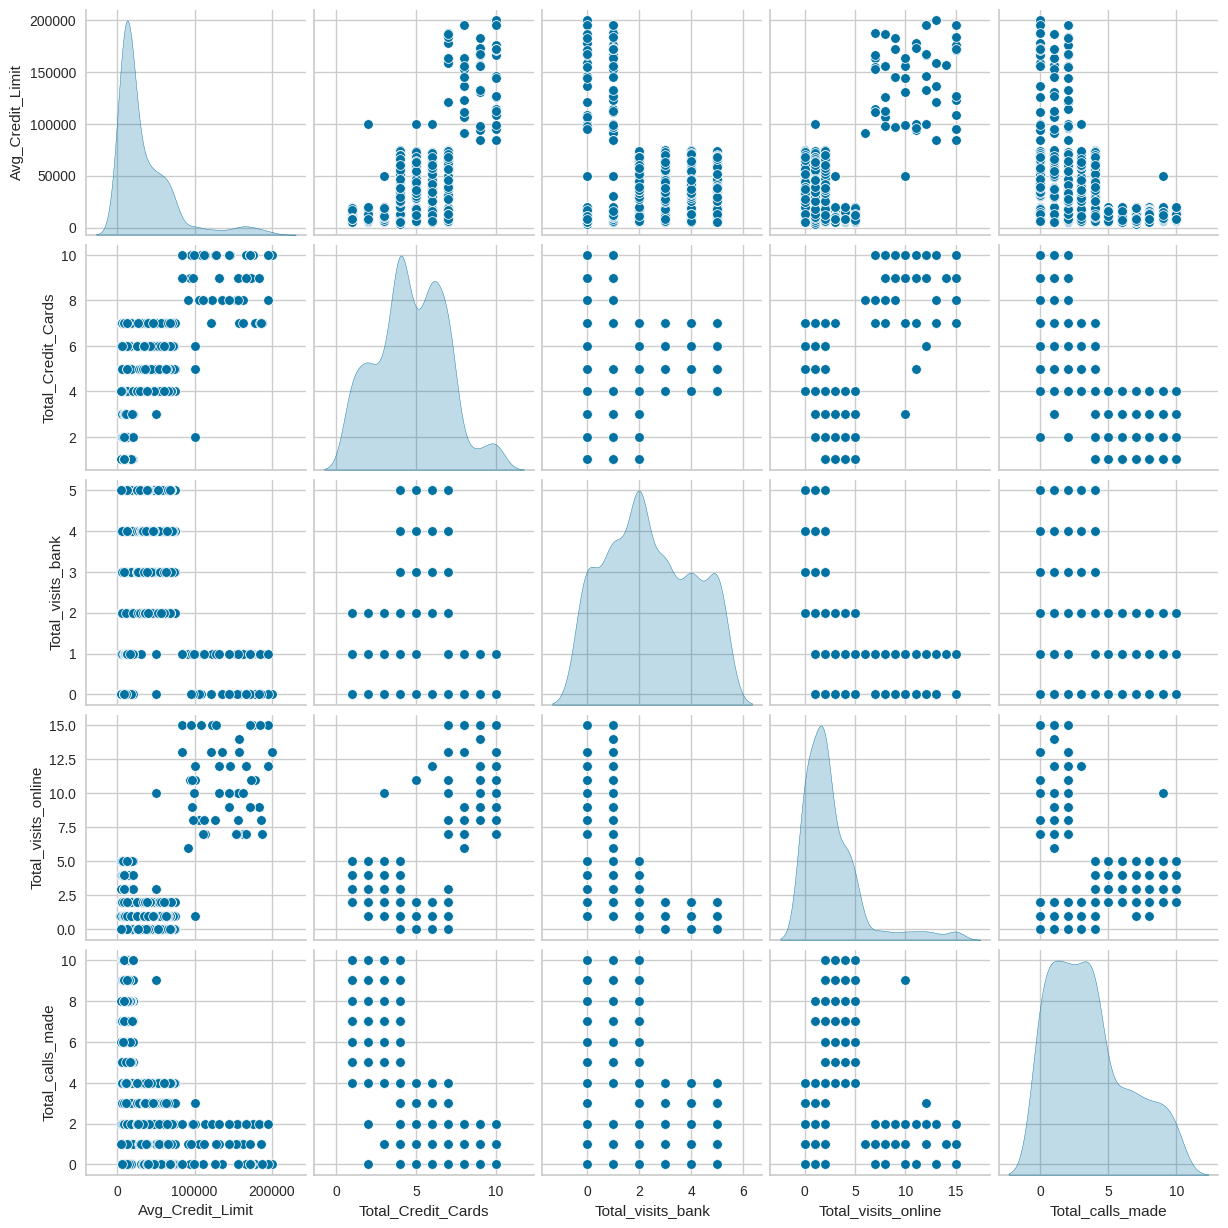

In [55]:
sns.pairplot(data=df[cols_list], diag_kind="kde")
plt.show()

**Observations**

A clear segmentation insight is -
- One segment with a cluster of digital users with high online visits and low calls
- Seperate group with high call volumes and less tech savvy customers.
- A clustering strategy can be used by using these relationships to define behavioral clusters — e.g., “Digital Savvy,” “High Touch,” “Credit Heavy.”

# **Data Preprocessing (Continued)**

## Scaling

- Let's scale the data before we proceed with clustering.

In [56]:
scaler = StandardScaler()

# Select all columns for clustering (since no exclusions needed)
col_4_clustering = df.columns.tolist()
print("Columns selected for clustering:", col_4_clustering)

# Apply scaling
scaled_data = scaler.fit_transform(df[col_4_clustering])

# convert back to DataFrame for readability
scaled_df = pd.DataFrame(scaled_data, columns=col_4_clustering)
print(scaled_df.head())


Columns selected for clustering: ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']
   Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
0          1.740187           -1.249225          -0.860451   
1          0.410293           -0.787585          -1.473731   
2          0.410293            1.058973          -0.860451   
3         -0.121665            0.135694          -0.860451   
4          1.740187            0.597334          -1.473731   

   Total_visits_online  Total_calls_made  
0            -0.547490         -1.251537  
1             2.520519          1.891859  
2             0.134290          0.145528  
3            -0.547490          0.145528  
4             3.202298         -0.203739  


- In our data, without scaling, clustering would have been driven almost entirely by credit limit.
- After scaling, all features contribute fairly, and you got meaningful clusters like call-dependent customers, branch users, digital premium users.


In [65]:
df_scaled = df[col_4_clustering].copy()
df_scaled.iloc[:, :] = scaler.fit_transform(df_scaled.iloc[:, :])
df_scaled.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.740187,-1.249225,-0.860451,-0.547490,-1.251537
1,0.410293,-0.787585,-1.473731,2.520519,1.891859
2,0.410293,1.058973,-0.860451,0.134290,0.145528
3,-0.121665,0.135694,-0.860451,-0.547490,0.145528
4,1.740187,0.597334,-1.473731,3.202298,-0.203739


In [66]:
# creating dataframe copies for k-means and hierarchical clustering
km_df = df.copy()
hc_df = df.copy()

# **Model Building**

## K-means Clustering

### Checking Elbow Plot

Number of Clusters: 2 	Average Distortion: 1.7178787250175898
Number of Clusters: 3 	Average Distortion: 1.1466276549150365
Number of Clusters: 4 	Average Distortion: 1.0902973540817666
Number of Clusters: 5 	Average Distortion: 0.9906853650098948
Number of Clusters: 6 	Average Distortion: 0.9515009282361341
Number of Clusters: 7 	Average Distortion: 0.9094119827472316
Number of Clusters: 8 	Average Distortion: 0.9191292344244387
Number of Clusters: 9 	Average Distortion: 0.8990131857179275
Number of Clusters: 10 	Average Distortion: 0.8723089051392604


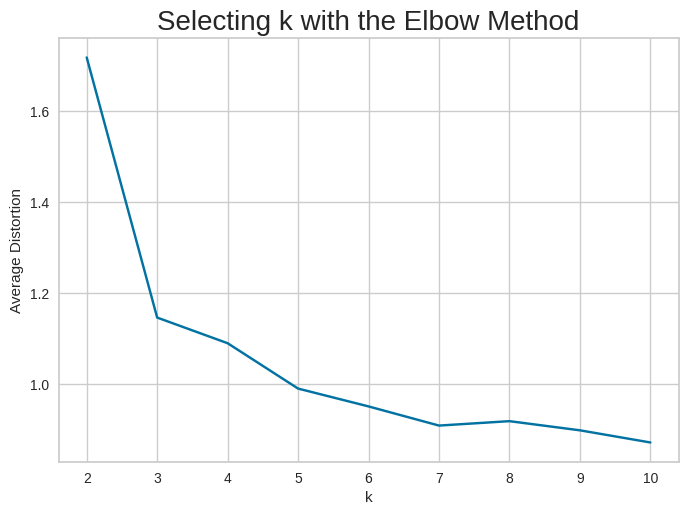

In [67]:
clusters = range(2, 11)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=1)
    model.fit(df_scaled)
    prediction = model.predict(df_scaled)
    distortion = (
        sum(np.min(cdist(df_scaled, model.cluster_centers_, "euclidean"), axis=1))
        / df_scaled.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting k with the Elbow Method", fontsize=20)
plt.show()

**Let's do further analysis to determine the optimal value of k**

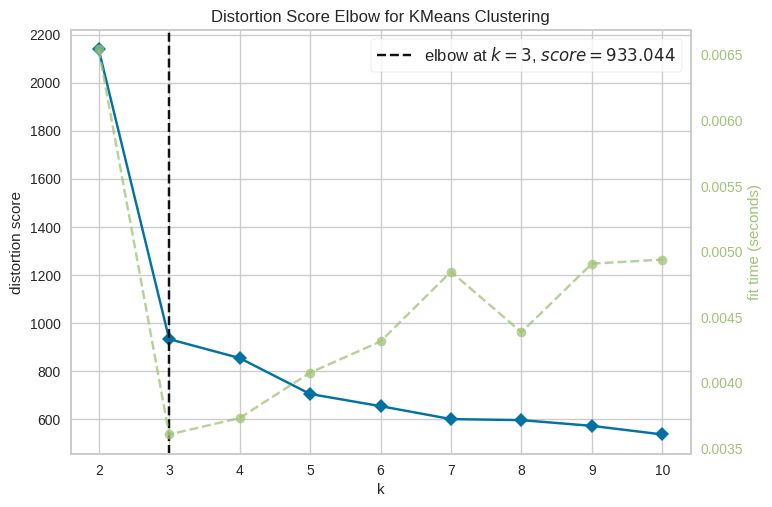

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [69]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2, 11), timings=True)
visualizer.fit(df_scaled)  # fit the data to the visualizer
visualizer.show()  # finalize and render figure

### Checking Silhouette Scores

**Let's check the silhouette scores.**

For n_clusters = 2, the silhouette score is 0.5703183487340514)
For n_clusters = 3, the silhouette score is 0.5157182558881063)
For n_clusters = 4, the silhouette score is 0.3744071798973986)
For n_clusters = 5, the silhouette score is 0.27167502160723267)
For n_clusters = 6, the silhouette score is 0.24804756291576194)
For n_clusters = 7, the silhouette score is 0.24791254258020035)
For n_clusters = 8, the silhouette score is 0.22570382558070443)
For n_clusters = 9, the silhouette score is 0.19931783829027247)
For n_clusters = 10, the silhouette score is 0.20939001908412339)


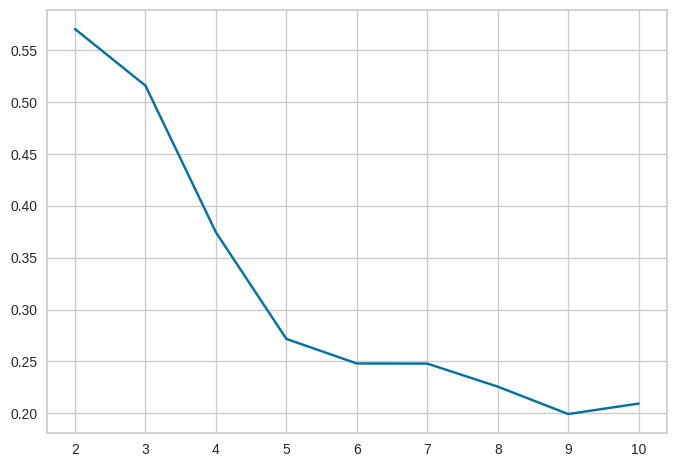

In [72]:
sil_score = []
cluster_list = range(2, 11)
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=1)
    preds = clusterer.fit_predict((df_scaled))
    score = silhouette_score(df_scaled, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

plt.plot(cluster_list, sil_score)
plt.show()

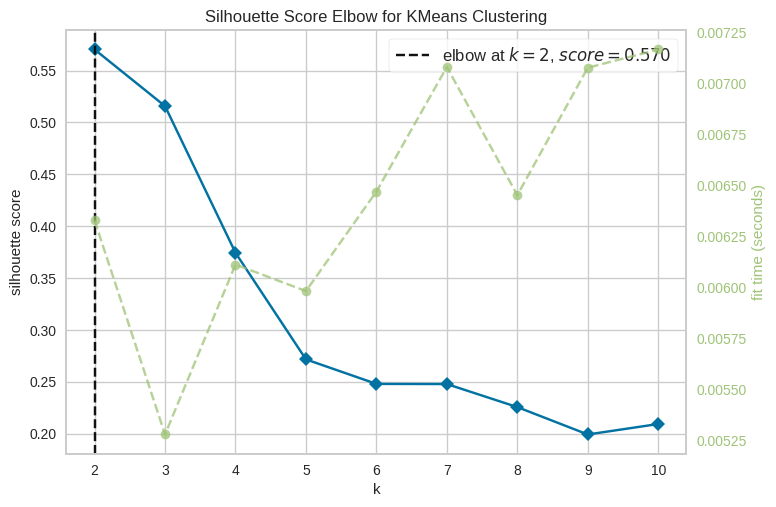

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [71]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2, 11), metric="silhouette", timings=True)
visualizer.fit(df_scaled)  # fit the data to the visualizer
visualizer.show()  # finalize and render figure

**From the silhouette scores, it seems that 3 is a good value for k.**

**Silhouette Plot**

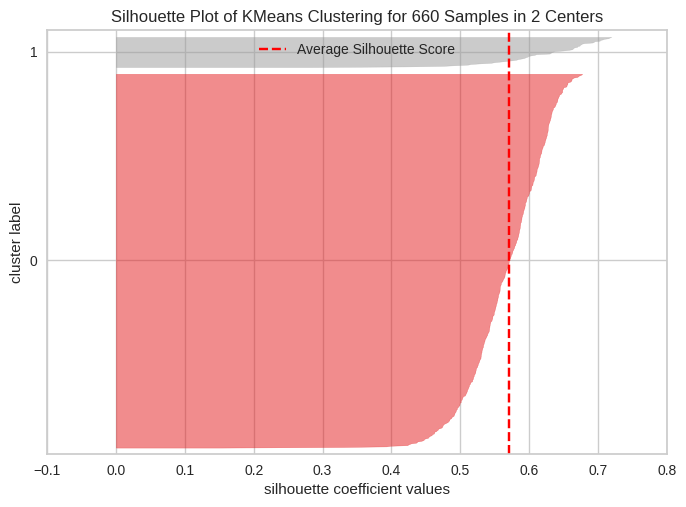

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [73]:
# Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(2, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

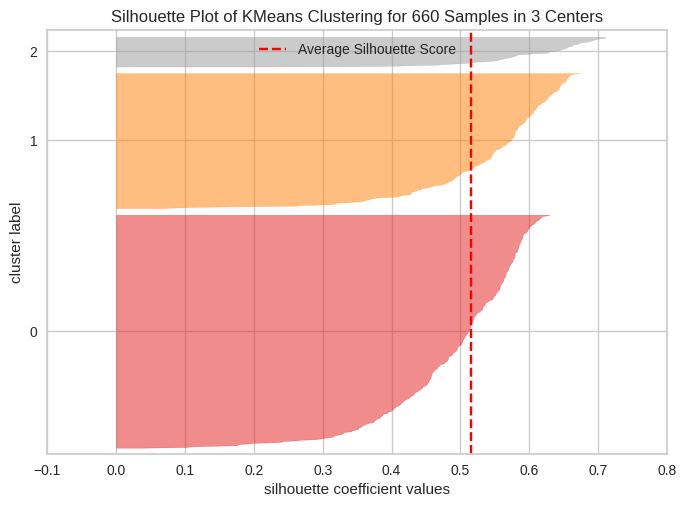

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [74]:
# Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(3, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

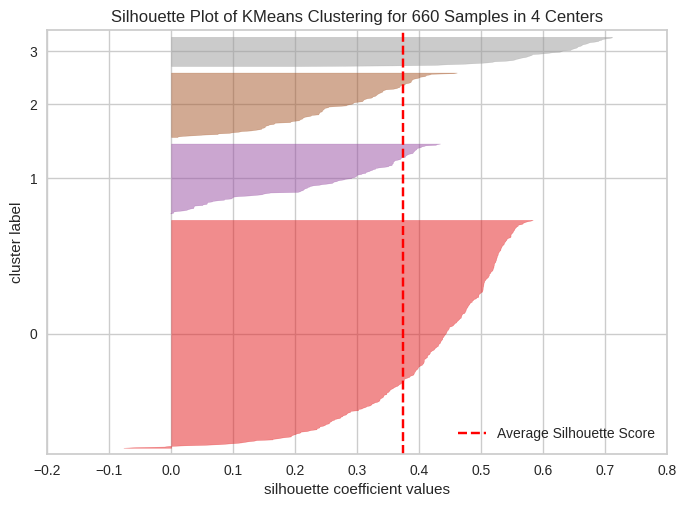

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [75]:
# Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(4, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

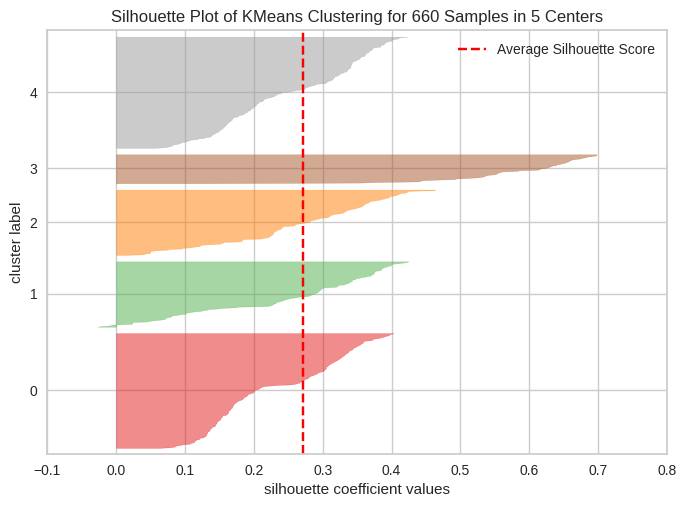

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [76]:
# Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(5, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

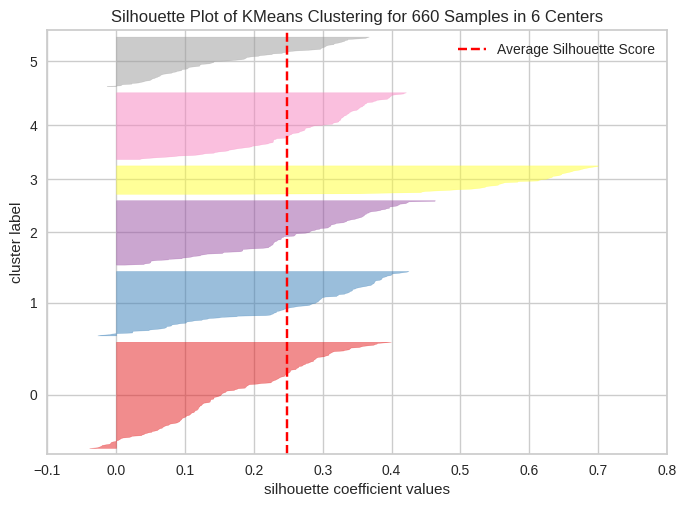

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [77]:
# Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(6, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

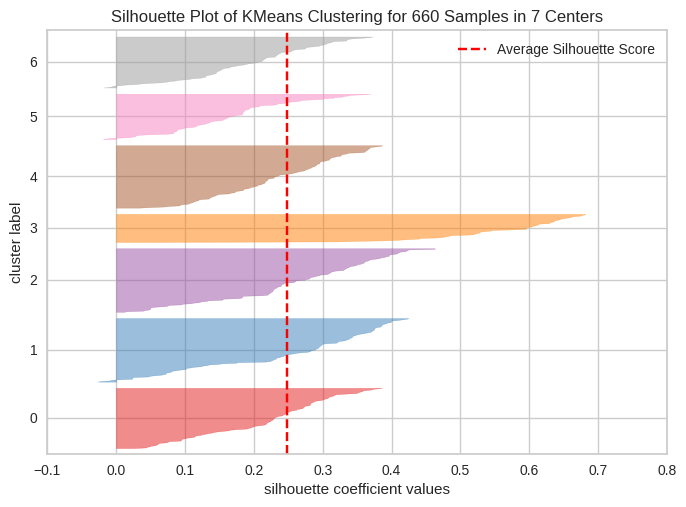

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 7 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [78]:
# Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(7, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

**Although silhouette peaked at k=2, we chose k=3 for more interpretable segmentation (low, mid, high customers)**

### Creating Final Model

In [79]:
kmeans = KMeans(n_clusters=3, random_state=1)
kmeans.fit(df_scaled)

KMeans(n_clusters=3, random_state=1)

In [80]:
# adding kmeans cluster labels to the original dataframe
km_df["KM_segments"] = kmeans.labels_

## Hierarchical Clustering

### Computing Cophenetic Correlation

In [81]:
# list of distance metrics
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(df_scaled, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(df_scaled))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

Cophenetic correlation for Euclidean distance and single linkage is 0.7391220243806552.
Cophenetic correlation for Euclidean distance and complete linkage is 0.8599730607972423.
Cophenetic correlation for Euclidean distance and average linkage is 0.8977080867389372.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.8861746814895477.
Cophenetic correlation for Chebyshev distance and single linkage is 0.7382354769296767.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.8533474836336782.
Cophenetic correlation for Chebyshev distance and average linkage is 0.8974159511838106.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.8913624010768603.
Cophenetic correlation for Mahalanobis distance and single linkage is 0.7058064784553605.
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.6663534463875359.
Cophenetic correlation for Mahalanobis distance and average linkage is 0.8326994115042136.
Cophenetic co

In [82]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.8977080867389372, which is obtained with Euclidean distance and average linkage.


### Checking Dendrograms

**We see that the cophenetic correlation is maximum with Euclidean distance and average linkage.**


**Let's view the dendrograms for the different linkage methods.**

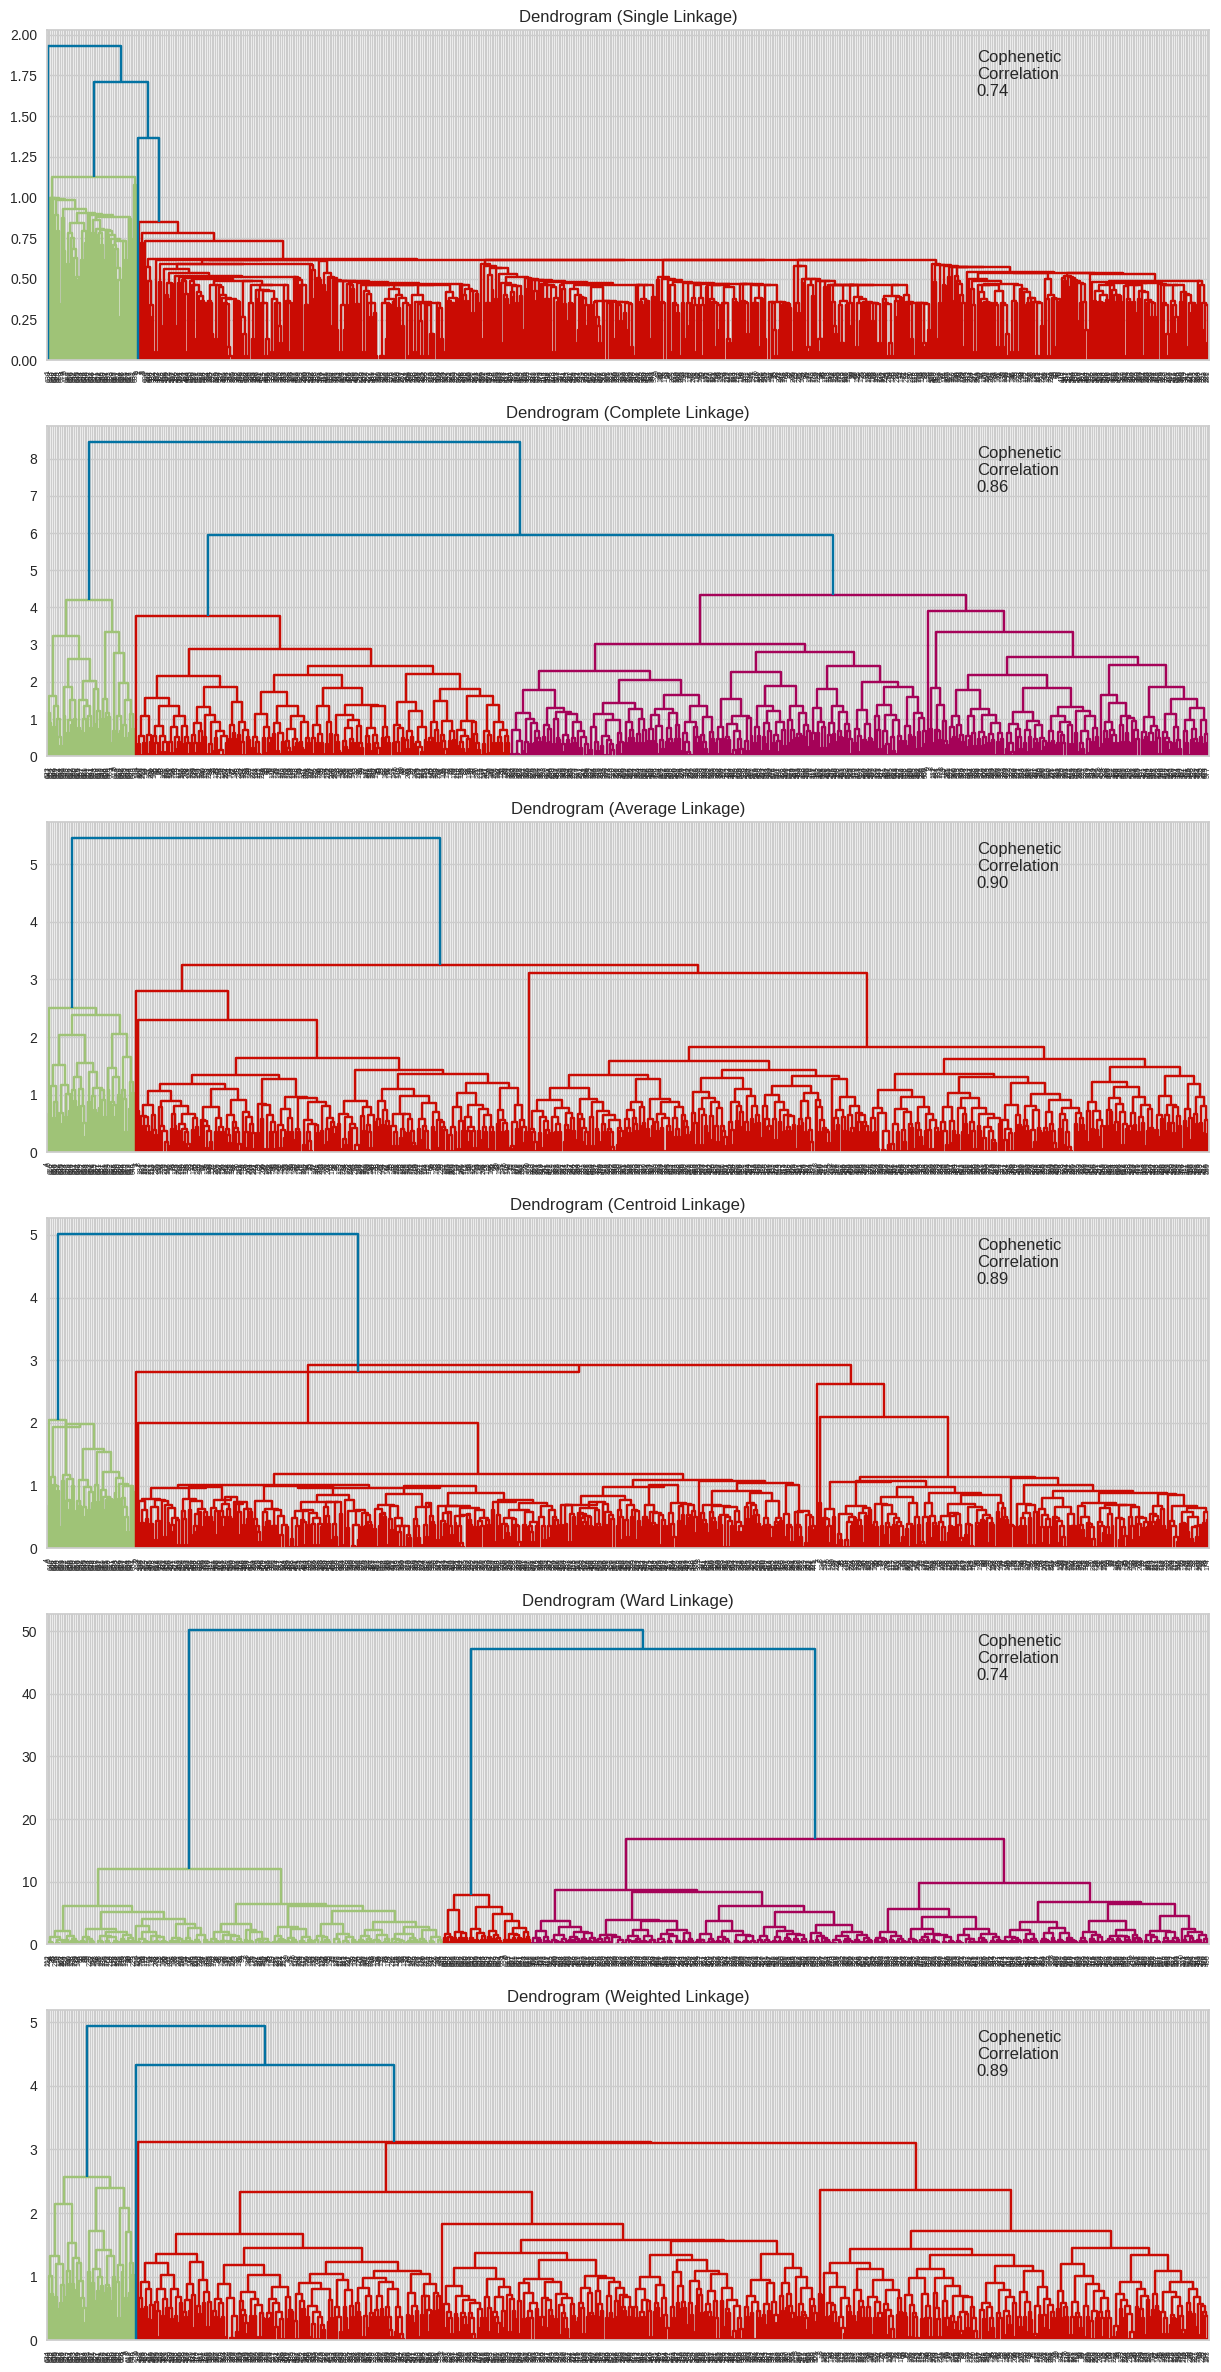

In [83]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]
compare = []

# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(df_scaled, metric="euclidean", method=method)

    dendrogram(Z, ax=axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(df_scaled))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

    compare.append([method, coph_corr])

**Observations**

- Looking the the above dendrograms, the ward linkage seems to result in the best separation between clusters, even though its cophenetic correlation is less 0.74 and less compared to the other linkages.
- 3 clusters seems distributing the data in a balanced way.

### Creating Final Model

In [85]:
hc = AgglomerativeClustering(n_clusters=4, metric="euclidean", linkage="ward")
hc_labels = hc.fit_predict(df_scaled)

In [86]:
hc_df["HC_segments"] = hc_labels

# **Cluster Profiling and Comparison**

## Cluster Profiling: K-means Clustering

In [114]:
kmeans = KMeans(n_clusters=3, random_state=42)
# Drop the non-numeric 'Online_Visit_Tier' column before fitting
df_scaled_numeric = df_scaled.drop('Online_Visit_Tier', axis=1)
df_scaled['KM_segments'] = kmeans.fit_predict(df_scaled_numeric)

In [115]:
df_scaled['Online_Visit_Tier'] = pd.cut(
    df['Total_visits_online'],
    bins=[0, 5, df['Total_visits_online'].max()],
    labels=['Low', 'Medium'],
    include_lowest=True
)
pd.crosstab(df_scaled['KM_segments'], df['Total_visits_online'])


Total_visits_online,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
KM_segments,,,,,,,,,,,,,,,,
0,144,106,135,1,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,7,6,4,5,5,6,5,1,10
2,0,3,54,43,69,54,0,0,0,0,1,0,0,0,0,0


**Observations**

- Cluster 0: Strong skew toward very low online visits (mostly 0 to 2). These users are likely offline customers.
- Cluster 1: Exclusively high online visit counts (6 to 15). These are your digital-first customers, possibly more self-service oriented.
- Cluster 2: A middle ground — users with moderate online activity, peaking around 4 to 5 visits. This segment might represent transitional users who use both services.


In [118]:
# let's plot the attributes of only the big clusters
c1 = [0, 1, 2]
km_df2 = km_df[km_df.KM_segments.isin(c1)]

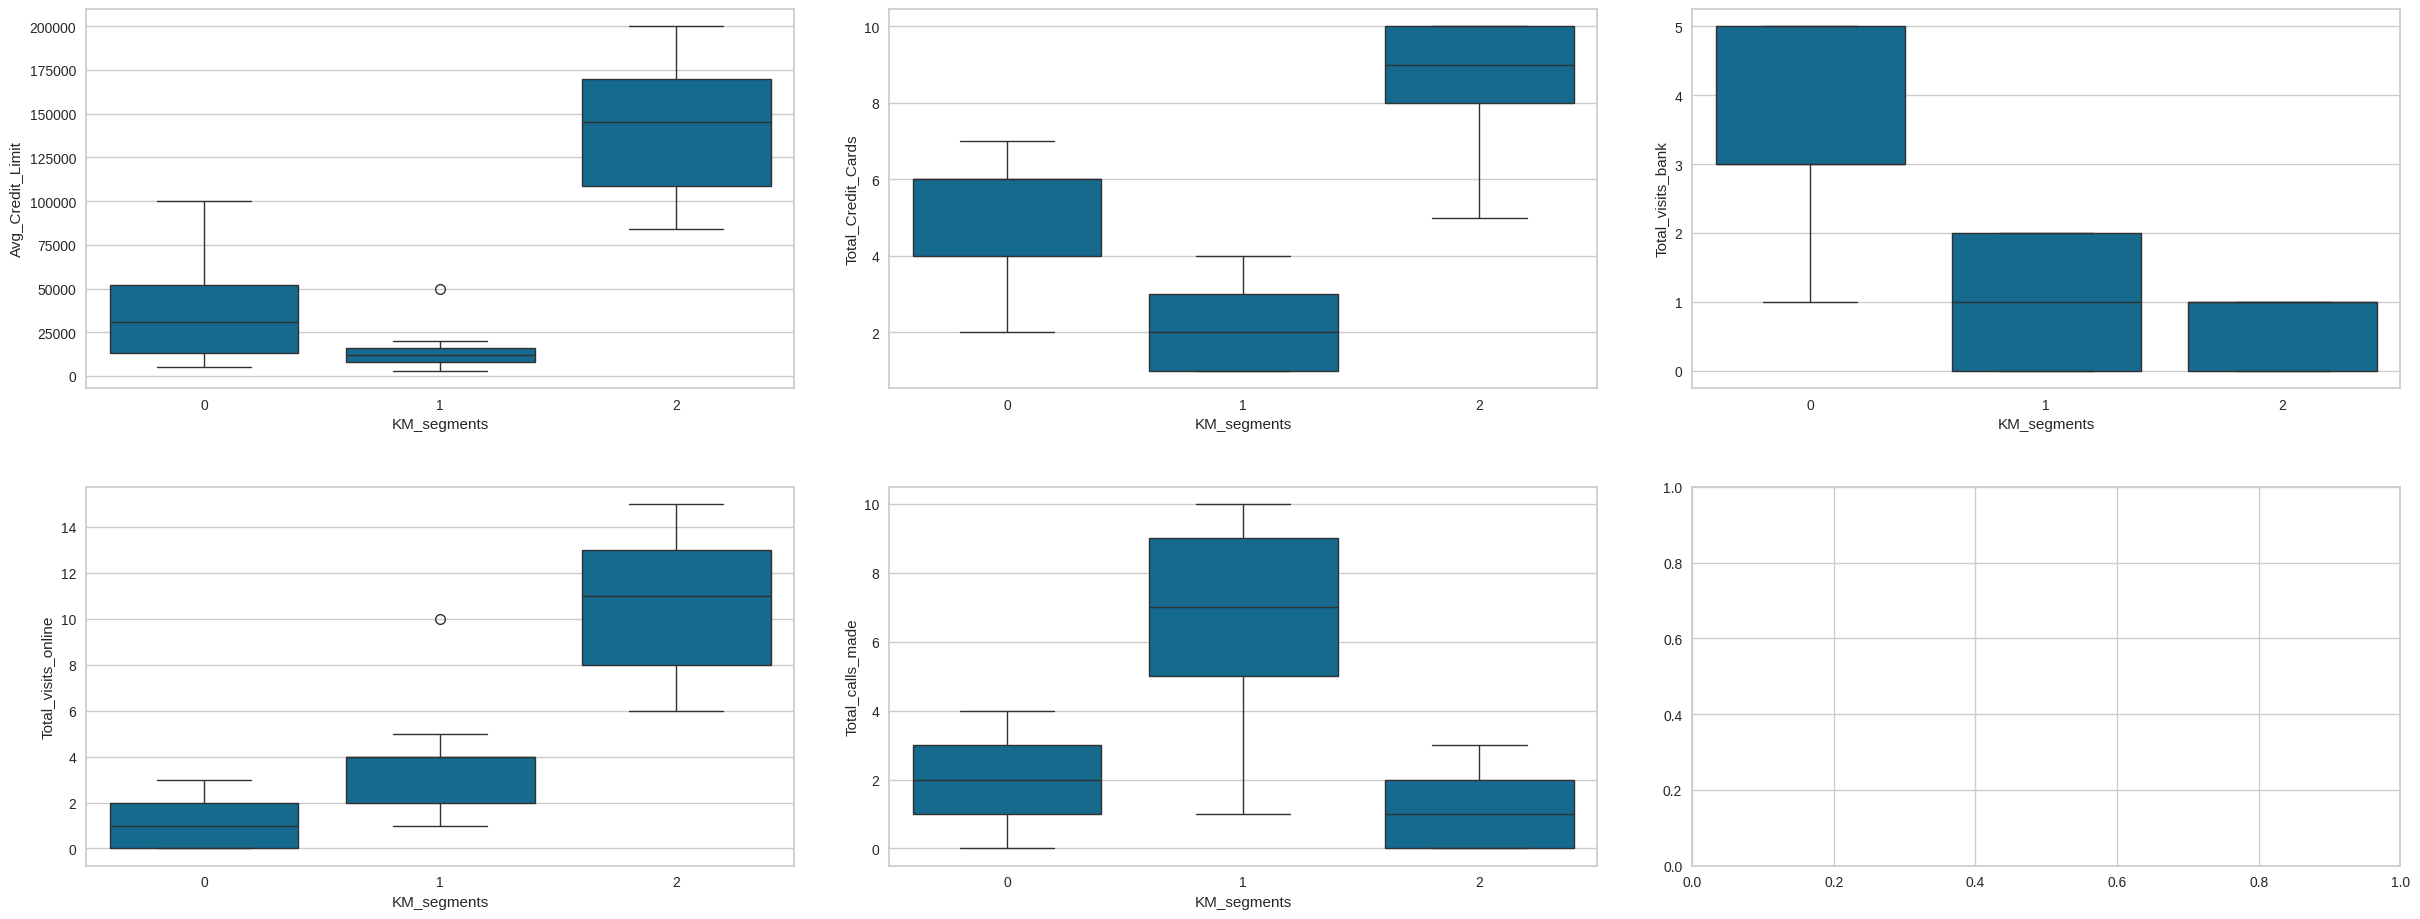

In [119]:
fig, axes = plt.subplots(2, 3, figsize=(25, 10))
counter = 0

for ii in range(2):
    for jj in range(3):
        if counter < len(col_4_clustering):
            sns.boxplot(
                ax=axes[ii][jj],
                y=km_df2[col_4_clustering[counter]],
                x=km_df2["KM_segments"],
            )
            counter = counter + 1

fig.tight_layout(pad=3.0)

### Insights

Segment 0:
Mid-level credit users, moderate activity, but high inactive accounts.

Segment 1:
Low credit, few cards, low spending, but relatively high call activity (maybe cost-sensitive customers).

Segment 2:
High-value customers: high credit limits, more cards, very active, high spending, but low calls/inactivity.

## Cluster Profiling: Hierarchical Clustering

In [122]:
pd.crosstab(km_df.KM_segments, km_df.Total_Credit_Cards)

Total_Credit_Cards,1,2,3,4,5,6,7,8,9,10
KM_segments,,,,,,,,,,
0,0,1,0,102,73,116,94,0,0,0
1,59,63,53,49,0,0,0,0,0,0
2,0,0,0,0,1,1,7,11,11,19


**Observations**

Segment 0 (KM_segments = 0)

- Customers mostly have 4 to 7 credit cards.
- Big concentration at 4, 5, 6 cards (102, 73, 116 respectively).
- This is the mid-level cluster → customers are established but not extreme credit card holders.

Segment 1 (KM_segments = 1)

- Customers mostly have 1 to 4 credit cards.
- Highest counts at 1, 2, 3 cards (59, 63, 53).
- This is the low-credit-card cluster → entry-level or less financially active customers.

Segment 2 (KM_segments = 2)

- Customers mostly have 7–10 credit cards.
- Distribution: 7 (7 customers), 8 (11), 9 (11), 10 (19).
- This is the high-credit-card cluster → heavy/elite users who maintain multiple cards.

- Based on this addressing and pitching to segment 0 and 1 seems more benefecial as they are comparitatively low card holders with high card holders.

In [123]:
pd.crosstab(km_df.KM_segments, km_df.Total_visits_online)

Total_visits_online,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
KM_segments,,,,,,,,,,,,,,,,
0,144,106,135,1,0,0,0,0,0,0,0,0,0,0,0,0
1,0,3,54,43,69,54,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,1,7,6,4,5,5,6,5,1,10


**Observations**

- Cluster 0 → Offline/Dormant Online Users (0 to 2 visits).
- Cluster 1 → Moderate Online Users (2 to 5 visits).
- Cluster 2 → Heavy Online Users (6 to 15 visits).

In [125]:
clusters = km_df.KM_segments.unique().tolist()

for cl in clusters:
    print(
        "The",
        km_df[km_df["KM_segments"] == cl]["Total_Credit_Cards"].nunique(),
        "unique credit card counts in cluster",
        cl,
        "are:",
    )
    print(km_df[km_df["KM_segments"] == cl]["Total_Credit_Cards"].unique())
    print("-" * 100, "\n")

The 5 unique credit card counts in cluster 0 are:
[2 7 5 4 6]
---------------------------------------------------------------------------------------------------- 

The 4 unique credit card counts in cluster 1 are:
[3 2 4 1]
---------------------------------------------------------------------------------------------------- 

The 6 unique credit card counts in cluster 2 are:
[ 6  5  9  8 10  7]
---------------------------------------------------------------------------------------------------- 



In [127]:
col_for_clustering = km_df.drop(columns=["KM_segments"]).columns

# calculate mean of each variable per cluster
km_df_profiling = km_df.groupby("KM_segments")[col_for_clustering].mean()

# add cluster size (number of customers in each cluster)
km_df_profiling["count_in_each_segment"] = (
    km_df.groupby("KM_segments")["Avg_Credit_Limit"].count().values
)

# display with highlight for max value per column
km_df_profiling.style.highlight_max(color="lightgreen", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segment
KM_segments,,,,,,
0,33782.383420,5.515544,3.489637,0.981865,2.000000,386
1,12174.107143,2.410714,0.933036,3.553571,6.870536,224
2,141040.000000,8.740000,0.600000,10.900000,1.080000,50


In [129]:
# let's plot the attributes of only the big clusters
c1 = [0, 2, 3]
hc_df2 = hc_df[hc_df.HC_segments.isin(c1)]

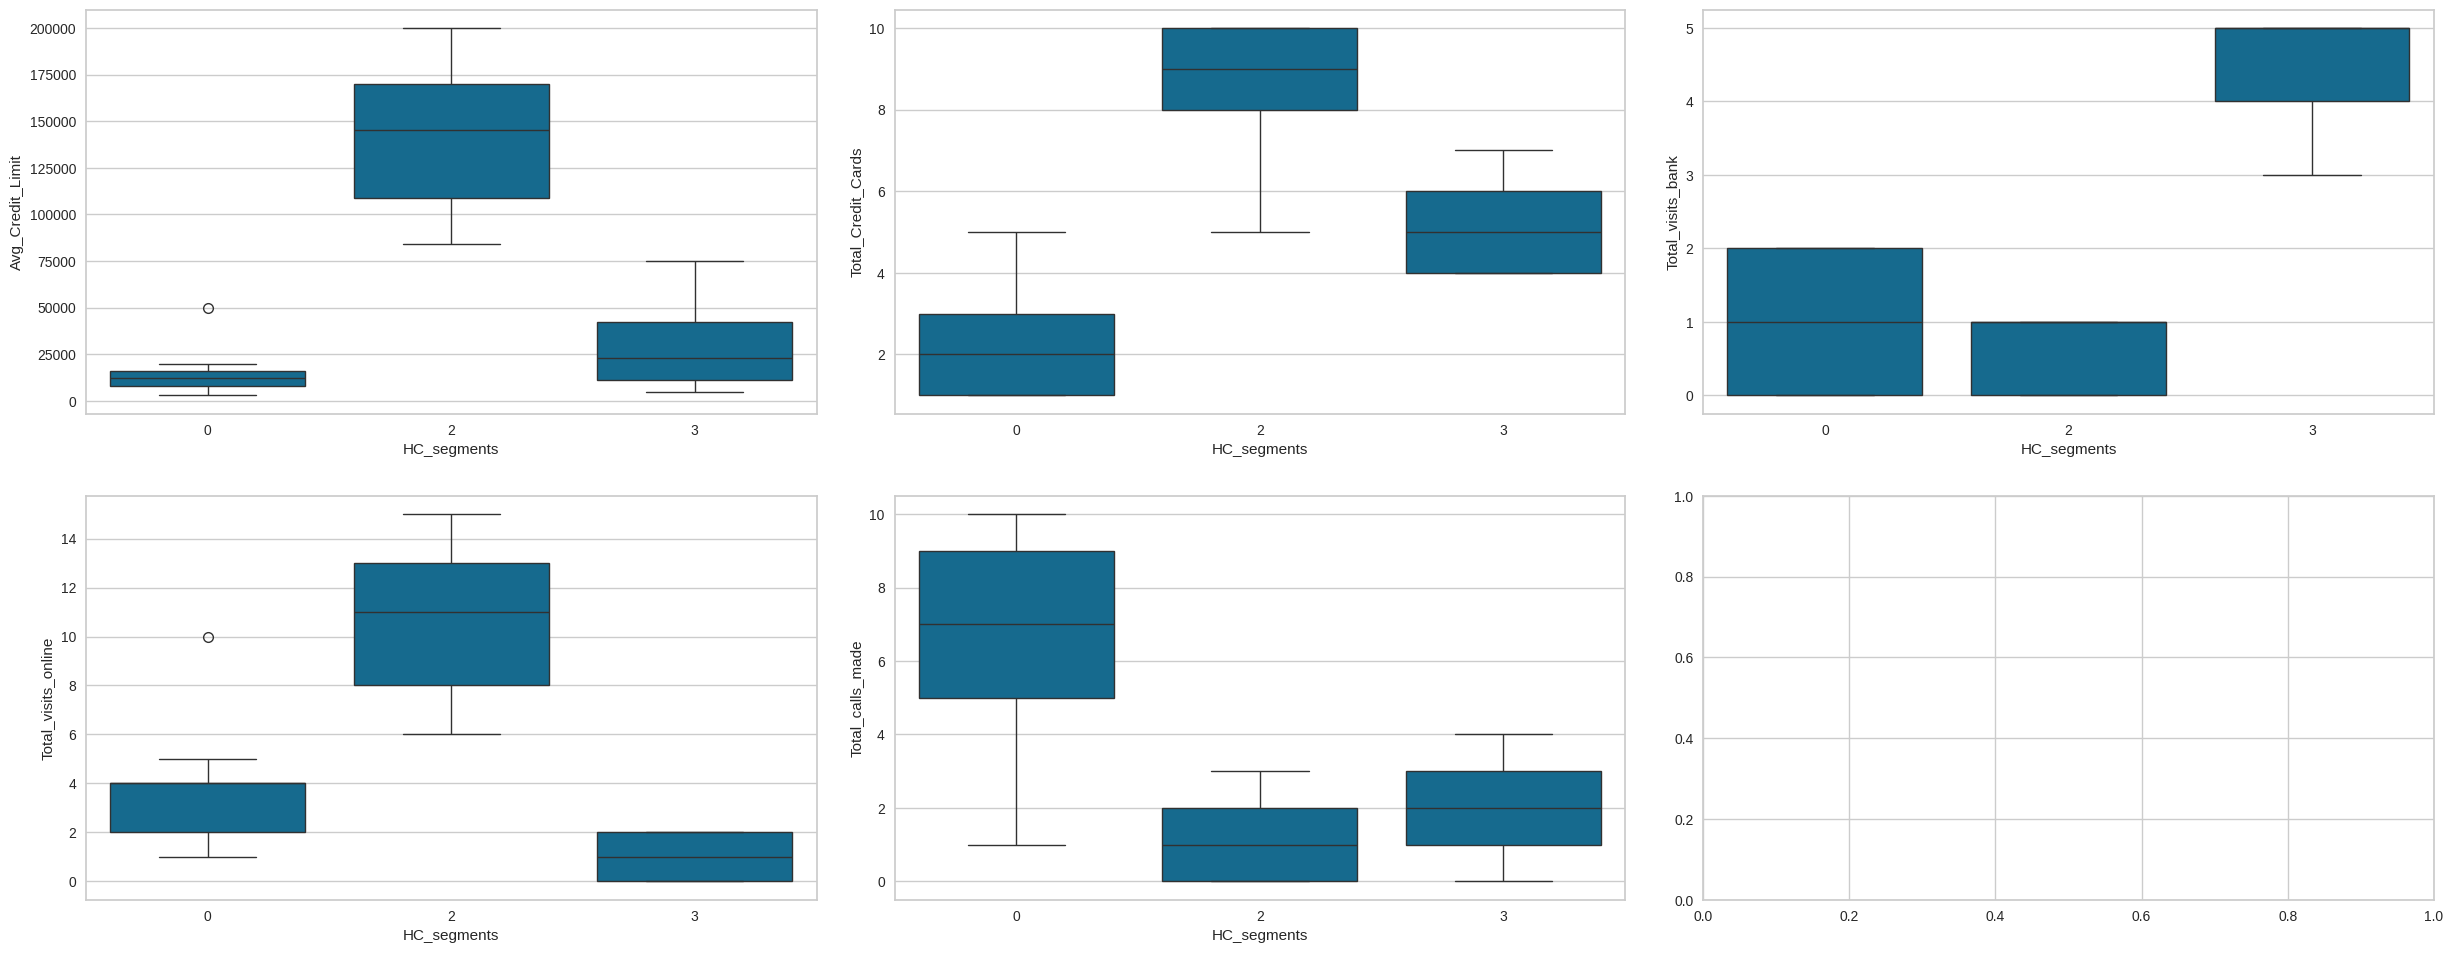

In [131]:
fig, axes = plt.subplots(2, 3, figsize=(25, 10))
counter = 0

for ii in range(2):
    for jj in range(3):
        if counter < len(col_4_clustering):
            sns.boxplot(
                ax=axes[ii][jj],
                y=hc_df2[col_4_clustering[counter]],
                x=hc_df2["HC_segments"],
            )
            counter = counter + 1

fig.tight_layout(pad=2.0)

### Insights

Cluster 0 (HC_segment = 0) →
- Very low credit limit
- Few cards (1 to 3)
- Moderate online visits
- High call activity
Likely low-value but service-demanding customers.

Cluster 2 (HC_segment = 2) →
- Very high credit limit (~150k)
- Many cards (8 to 10)
- Very low bank visits, very high online visits
- Few calls -  Premium digital-savvy customers.

Cluster 3 (HC_segment = 3) →
- Medium credit limit (~40 to 70k)
- Moderate cards (4 to 6)
- High bank visits, very low online usage
- Moderate calls -  Traditional branch-visiting customers.

## K-means vs Hierarchical Clustering

In [143]:
# Select clustering features (exclude segment columns if present)
col_for_clustering = df.drop(columns=["KM_segments", "HC_segments"], errors="ignore").columns

# ----- KMeans profiling -----
km_df_profiling = km_df.groupby("KM_segments")[col_for_clustering].mean()
km_df_profiling["count_in_each_segment"] = km_df.groupby("KM_segments")[col_for_clustering[0]].count()

# ----- Hierarchical profiling -----
hc_df_profiling = hc_df.groupby("HC_segments")[col_for_clustering].mean()
hc_df_profiling["count_in_each_segment"] = hc_df.groupby("HC_segments")[col_for_clustering[0]].count()

# Display with highlight for clarity
print("KMeans Cluster Profiling")
display(km_df_profiling.style.highlight_max(color="lightgreen", axis=0))

print("\nHierarchical Cluster Profiling")
display(hc_df_profiling.style.highlight_max(color="lightblue", axis=0))

KMeans Cluster Profiling


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segment
KM_segments,,,,,,
0,12174.107143,2.410714,0.933036,3.553571,6.870536,224
1,141040.000000,8.740000,0.600000,10.900000,1.080000,50
2,33782.383420,5.515544,3.489637,0.981865,2.000000,386



Hierarchical Cluster Profiling


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segment
HC_segments,,,,,,
0,12151.111111,2.422222,0.937778,3.546667,6.857778,225
1,38298.429319,5.670157,2.523560,0.947644,2.099476,191
2,141040.000000,8.740000,0.600000,10.900000,1.080000,50
3,29474.226804,5.365979,4.448454,1.010309,1.891753,194


**Observations**

- Both models clearly segmented the customers into 3 major clusters:
-- Low credit, heavy callers
-- High credit, digital users and
-- Mid level, offline store visitors

However K means identified only 3 clusters making it simpler.


# **PCA for Visualization**

- Let's use PCA to reduce the data to two dimensions and visualize it to see how well-separated the clusters are.

In [140]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
# Drop the non-numeric 'Online_Visit_Tier' column before fitting
df_scaled_numeric = df_scaled.drop('Online_Visit_Tier', axis=1)
X_reduced_pca = pca.fit_transform(df_scaled_numeric)

# storing results in a dataframe
reduced_data_df_pca = pd.DataFrame(
    data=X_reduced_pca, columns=["Component 1", "Component 2"]
)

# checking the amount of variance explained
print(
    f"The first two principal components explain {np.round(100*pca.explained_variance_ratio_.sum(), 2)}% of the variance in the data."
)

The first two principal components explain 84.02% of the variance in the data.


<Axes: xlabel='Component 1', ylabel='Component 2'>

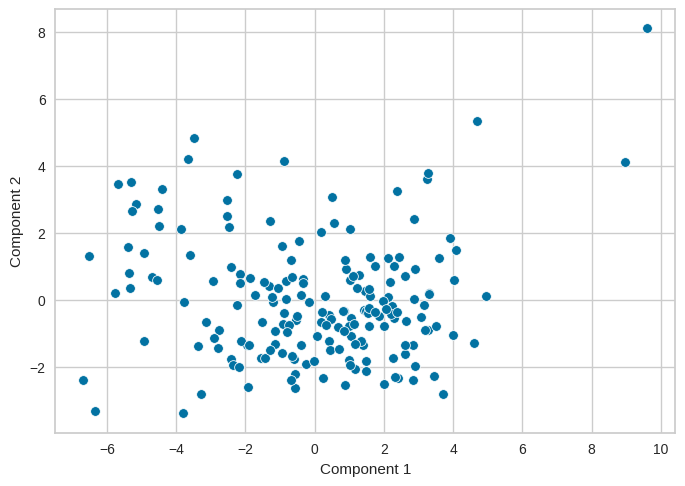

In [ ]:
sns.scatterplot(data=reduced_data_df_pca, x="Component 1", y="Component 2")

<Axes: xlabel='Component 1', ylabel='Component 2'>

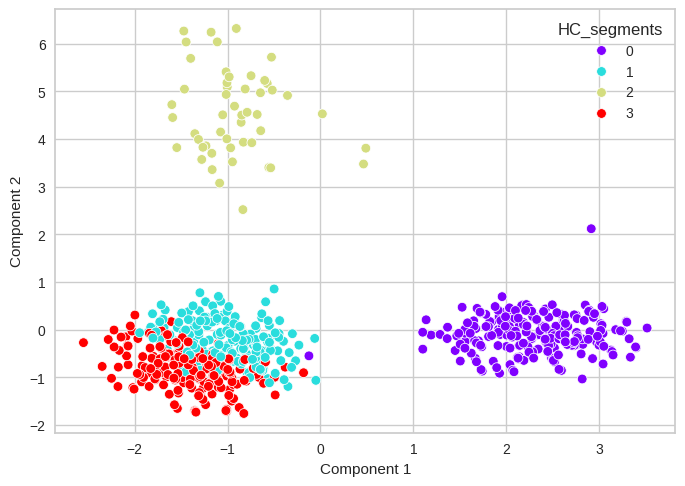

In [141]:
sns.scatterplot(
    data=reduced_data_df_pca,
    x="Component 1",
    y="Component 2",
    hue=hc_df["HC_segments"],
    palette="rainbow",
)

**Actions and Insights:**

- All the clusters are very well seperated.
- Premium digital customers in yellow are more distinct
- Traditional users are closer together as they prefer both online and offline means
- Purple users are low credit and are compact and clearly seperate making them unique.

# **Final Recommendations:**

Segment 1: Low-credit, call-dependent users
- For these segment customers, we need to improve call-center experience aiding in quick resolution and proactive follow-ups.
- We can Offer basic digital training to these customers.
- We can guide and shift some services from calls to app/online.
- We can also try piching some of the low-risk products (e.g., small personal loans, entry-level cards).

Segment 2: Medium-credit, branch-focused users
- Encourage digital usage with special benefits on online platforms and discounts on applications.
- And we can gradually reduce dependency on physical branches by promoting mobile app features.
- Potentially we can increase credit limits and offer higher limit cards.

Segment 3: Premium, digital-savvy users
- We should focus on retaining these high profile customers by various methods.
- We can offer exclusive benefits (airport lounge, coupons or travel discounts).
- We can promote high-value cards to these customers.
- Usually these customers are less demanding hence provide them with personalised services.

Hybrid mid-tier (from HC model)
- These customers use both bank + online moderately.
- Hence they are the best target group for migration to digital with increased incentives.